# Bias Analysis - Study2b

## Loading Libraries & Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import matplotlib.colors as mcolors
import requests
from pathlib import Path
import json
import re
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg
from scipy import stats
import itertools
import string

In [2]:
ageRisk = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

In [3]:
ageRisk.shape

(980, 12)

## Resolving ETFs 

In [4]:
def get_position_weight(portfolio_df):
    position_weight = portfolio_df / portfolio_df.sum()
    return position_weight

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'ticker_symbol', 'amount_to_invest', 'weight', 'sector', 'asset_type', 'country']
ageRisk['weight'] = ageRisk.groupby(['ai', 'age', 'risk-taking', 'cond', 'iteration'])['amount_to_invest'].transform(get_position_weight)
ageRisk = ageRisk[ageRisk_select_cols]

ageRisk_unique_etfs = ageRisk[ageRisk["asset_type"] == "ETF"]["ticker_symbol"].unique()
etfs = ageRisk_unique_etfs

ageRisk_unique_funds = ageRisk[ageRisk["asset_type"] == "MUTUALFUND"]["ticker_symbol"].unique()
funds = ageRisk_unique_funds

In [5]:
def prepare_refinitiv_dataset(df, columns):
    df = df.iloc[1:].reset_index()
    df.columns = columns
    df['economic_sector'] = df['economic_sector'].replace('Unable to resolve all requested identifiers.', np.nan)
    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['economic_sector'].str.startswith('Unable to')
    df.loc[condition & ~df['economic_sector'].isna(), 'country'] = np.nan
    df['weight'] = pd.to_numeric(df['weight'], errors='coerce')
    df['weight'] = df['weight'].fillna(100.0)
    df['weight'] = df['weight'] / 100
    df['fund'] = df['fund'].str.split('.').str[0]
    return df

study1_etf_data = pd.read_csv('../study1/etf_holdings/refinitiv/etfs_refinitiv.csv', index_col=0, low_memory=False)
study1_fund_data = pd.read_csv('../study1/mutualFund_holdings/refinitiv/mutualFunds_refinitiv.csv', index_col=0, low_memory=False)

cols_refinitiv = ['fund', 'code', 'equity', 'symbol', '#shares', 'weight', 'country', 'type', 'economic_sector']
study1_etf_data = prepare_refinitiv_dataset(study1_etf_data, cols_refinitiv)
study1_etfs = study1_etf_data['fund'].unique()

study1_fund_data = study1_fund_data.iloc[:,:-2]
study1_fund_data = prepare_refinitiv_dataset(study1_fund_data, cols_refinitiv)
study1_funds = study1_fund_data['fund'].unique()

new_etfs = [item for item in etfs if item not in study1_etfs]
new_funds = [item for item in funds if item not in study1_funds]

In [6]:
resStr_etf = ""
os = ['ACWX', 'DVY', 'VCLT', 'IXUS', 'IGOV']
ks = ['SCHA', 'IA', 'IAGG']
for etf in new_etfs:
    if etf in os:
        resStr_etf += f'{etf}.O;'
    elif etf in ks:
        resStr_etf += f'{etf}.K;'
    else:
        resStr_etf += f'{etf};'
resStr_etf

'HDV;IVW;GBTC;ACWX.O;DVY.O;VEA;EFA;IAU;IWR;SCHA.K;VCLT.O;XLP;IXUS.O;IAGG.K;FAN;VT;MUB;SDY;IGOV.O;IJS;'

In [7]:
resStr_mutualFunds = "";
delisted = ['VTWSX', 'VDAIX']
for fund in new_funds:
    if fund in delisted:
        resStr_mutualFunds += f'{fund}.O^K19;'
    else:
        resStr_mutualFunds += f'{fund}.O;'
resStr_mutualFunds

'VEMAX.O;FXNAX.O;FBALX.O;VTWSX.O^K19;VGTSX.O;VDAIX.O^K19;PRWBX.O;FSPSX.O;VIGRX.O;'

In [8]:
resStr_funds = resStr_etf + resStr_mutualFunds
resStr_funds

'HDV;IVW;GBTC;ACWX.O;DVY.O;VEA;EFA;IAU;IWR;SCHA.K;VCLT.O;XLP;IXUS.O;IAGG.K;FAN;VT;MUB;SDY;IGOV.O;IJS;VEMAX.O;FXNAX.O;FBALX.O;VTWSX.O^K19;VGTSX.O;VDAIX.O^K19;PRWBX.O;FSPSX.O;VIGRX.O;'

In [9]:
# BSCM ended on 15.12.2022, GLD, SLV, DbC

## Loading Data from Refinitiv & Resolving Dataset

In [10]:
additional_fund_data = pd.read_csv('./data/refinitiv/funds_refinitiv_study2b.csv', index_col=0, low_memory=False)
additional_fund_data = prepare_refinitiv_dataset(additional_fund_data, cols_refinitiv)

additional_data = pd.read_csv('../study1/etf_holdings/refinitiv/additions_refinitiv.csv', index_col=0)
additional_data = prepare_refinitiv_dataset(additional_data, cols_refinitiv)

fund_data = pd.concat([study1_etf_data, study1_fund_data, additional_data, additional_fund_data], ignore_index=True)

In [11]:
def create_ticker(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['symbol']
    else:
        return row['ticker_symbol']

def create_ticker_l2(row):
    if row['asset_type'] in ['ETF', 'MUTUALFUND']:
        return row['ticker'] if pd.isnull(row['equity_l2']) else row['symbol_l2']
    else:
        return row['ticker']
    
def harmonize_sectors(sector):
    if sector == 'Consumer Cyclicals':
        return 'Consumer Cyclical'
    elif sector == 'Financial Services':
        return 'Financials'
    elif sector == 'Consumer Defensive':
        return 'Consumer Non-Cyclicals'
    else:
        return sector
    
def resolve_layer2(df, select_cols):
    df = df.merge(additional_data, left_on='ticker', right_on='fund', how='left', suffixes=('_l1','_l2'))
    df['weight_l2'].fillna(1, inplace=True)
    df['weight'] = df['weight_l1'] * df['weight_l2']
    df['sector'] = df['sector'].fillna(df['economic_sector_l2'])
    df['country'] = df.apply(
        lambda row: row['country_l2'] if pd.isnull(row['country_l1']) else row['country_l1'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker_l2(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount'] * row['weight_l2'], axis=1)

    condition = df['country'].str.startswith('Unable to')
    df.loc[condition & ~df['country'].isna(), 'country'] = np.nan
    condition = df['sector'].str.startswith('Unable to')
    df.loc[condition & ~df['sector'].isna(), 'sector'] = np.nan

    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    df['country'] = df['country'].fillna('UNKNOWN')
    df['ticker'] = df['ticker'].fillna('UNKNOWN')
    #df = df[select_cols]
    return df

def prepare_data(df, select_cols):
    df = df.merge(fund_data, left_on='ticker_symbol', right_on='fund', how='left')
    df['weight_y'].fillna(1, inplace=True)
    df['weight'] = df['weight_x'] * df['weight_y']
    df['sector'] = df['sector'].fillna(df['economic_sector'])
    df['sector'] = df.apply(
        lambda row: 'Crypto' if row['asset_type'] == 'CRYPTOCURRENCY' else row['sector'],
        axis=1
    )
    df['country_x'] = df['country_x'].str.upper()
    df['country'] = df.apply(
        lambda row: row['country_y'] if pd.isnull(row['country_x']) else row['country_x'],
        axis=1
    )
    df['ticker'] = df.apply(lambda row: create_ticker(row), axis=1)
    df['amount'] = df.apply(lambda row: row['amount_to_invest'] * row['weight_y'], axis=1)
    df['sector'] = df['sector'].apply(harmonize_sectors) 
    return resolve_layer2(df, select_cols)

def prepare_benchmark(df):
    df = df.rename(columns={'economic_sector': 'sector'})
    df['amount'] = df['weight'].apply(lambda x: x * 10000)
    df['sector'] = df['sector'].fillna('UNKNOWN')
    df['country'] = df['country'].fillna('UNKNOWN')
    df['sector'] = df['sector'].apply(harmonize_sectors)
    return df

ageRisk_select_cols = ['ai', 'age', 'risk-taking', 'cond', 'iteration', 'asset_type', 'ticker', 'weight', 'country', 'sector', 'amount']
ageRisk_resolved = prepare_data(ageRisk, ageRisk_select_cols)

benchmark_cols_refinitiv = ['fund', 'equity', 'symbol', '#shares', 'weight', 'country', 'economic_sector', 'business_sector', 'industry_group']
benchmark = pd.read_csv('../study1/benchmark/refinitiv/benchmarks_refinitiv.csv', index_col=0)
benchmark_prepared = prepare_benchmark(prepare_refinitiv_dataset(benchmark, benchmark_cols_refinitiv))


In [12]:
benchmark_ftse = benchmark_prepared[benchmark_prepared['fund'] == 'VFAWF']
benchmark_msci = benchmark_prepared[benchmark_prepared['fund'] == 'IUSQ']
benchmark_vt = pd.read_csv('../study1/benchmark/refinitiv/benchmark_vt.csv', index_col=0)

In [13]:
def prepare_dataframe(df, col_name, sep_col = None, sep_col_values = None):
    ages = [15, 30, 50]
    risk_taking = ['averse', 'neutral', 'seeking']
    cond = df['cond'].unique()
    iterations = list(range(10))  # 0 to 9
    
    if sep_col:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations, sep_col_values))

        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration', sep_col])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'iteration', 'cond', sep_col], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df
    else:
        combinations = list(itertools.product(ages, risk_taking, cond, iterations))
        
        missing_rows = pd.DataFrame(combinations, columns=['age', 'risk-taking', 'cond', 'iteration'])
        missing_rows[col_name] = 0

        result_df = df.merge(missing_rows, on=['age', 'risk-taking', 'cond', 'iteration'], how='outer', suffixes=('', '_missing'))
        result_df[col_name].fillna(0, inplace=True)
        return result_df

## Graphs

In [14]:
mpl.rcParams['font.size'] = 14  # Change the size to your preference
mpl.rcParams['font.sans-serif'] = 'Arial'

In [15]:
# Returns a data frame that contains all combinations of two data frames on a certain criterion (elem)
def fill_options(filtered_df, res_df, elem, group_cols):
    elems = filtered_df[elem].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame([row + [el] for row in group_cols_df.values.tolist() for el in elems], columns=group_cols+[elem])
    merged = pd.merge(all_combinations, res_df, on=group_cols+[elem], how='left')
    merged.fillna(0, inplace=True)
    return merged

# Calculates the weight of a certain characteristic (elem) in a group
def calculate_weight(group, elem):
    summed = group.groupby(elem)['amount'].sum().reset_index()
    total_amount = summed['amount'].sum()
    summed['weight'] = summed['amount'] / total_amount
    return summed

# Prepares benchmark data to be handled as a experimental condition
def create_benchmark_dummy(df, benchmark_label):
    benchmark_ai = f'{benchmark_label}'
    df['cond'] = benchmark_ai
    df['ai'] = benchmark_ai
    df['age'] = 1
    df['risk-taking'] = 'low'
    df['iteration'] = 0
    return df

# Calculates an ANOVA on a characteristic (column) for the defined groups (group1, group2) and prints the TukeyHSD results
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)
    
# Calculates a t-test between a sample and a fixed value for a defined grouping
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        d = group_values.mean() - benchmark
        print(f'group: {group_name} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 2)} d: {round(d, 2)}')

def show_ttest_ind(raw, column, groups):
    unique_groups = raw[groups].unique()
    if len(unique_groups) != 2:
        print('Error occured calculating the t-test between the groups.')
        return

    group1, group2 = unique_groups
    data1 = raw[raw[groups] == group1][column].dropna()
    data2 = raw[raw[groups] == group2][column].dropna()
    print(stats.ttest_ind(data1, data2))
    t_stat, p_value = stats.ttest_ind(data1, data2)
    print(f'group1: {group1} and group2: {group2} got t: {round(t_stat,2)}, p_value: {round(p_value,4)}, df: {len(data1) + len(data2) - 2}')
    

# Calculates statistics for a given characteristic (column) within groups
def calc_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    if group2:
        show_anova(raw, column, group1, group2, onlyGroup)
    else:
        show_ttest_ind(raw, column, group1)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

# Prints means, standard deviations, and sample sizes for defined groups
def print_stats(raw, column, benchmark, group1, group2=None, onlyGroup=False):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2, onlyGroup)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors
    
# Prints mean violinplots of a feature relative to a fixed benchmark value
def show_benchmark_violinplot(raw, benchmark, benchmark_label, column, column_label, group1, filename):
    means, _, _,_ = print_stats(raw, column, benchmark, group1)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.violinplot(data=raw, x=group1, y=column, split=False, inner=None, linewidth=1, ax=ax, edgecolor='black', fill=None, zorder=2)

    # Add boxplots
    sns.boxplot(data=raw, x=group1, y=column, hue=group1, width=0.2, palette="Set3", ax=ax, 
                boxprops=dict(edgecolor='black', facecolor=(1, 1, 1, 0)), 
                medianprops=dict(linewidth=2, color='black'), 
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'), fliersize=0, legend=False, zorder=4)

    for i, group in enumerate(raw[group1].unique()):
        group_data = raw[raw[group1] == group][column]
        jitter = np.random.normal(i, 0.04, size=len(group_data))
        ax.scatter(jitter, group_data, s=100, alpha=0.4, zorder=3)  # Set zorder to ensure dots are on top

        # Calculate the mean and add it to the boxplot
        mean = group_data.mean()
        ax.scatter(i, mean, color='black', s=50, label='mean', zorder=5)

    ax.axhline(y=benchmark, color='black', linestyle='--', label=benchmark_label, zorder=4)
    ax.set_ylabel(column_label)
    ax.set_xticks(range(len(means.index)))
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(f'./figures/{filename}.png')
    plt.show()

# Prints mean barplots of a feature relative to a fixed benchmark value
def print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label):
    # Create a stacked barplot with error bars
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(4, 5), zorder=2, color=['darkgrey'])
    ax.axhline(y=benchmark, color='red', linestyle='--', label=benchmark_label)
    ax.set_ylabel(column_label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    ax.set_xlabel('Condition')
    ax.grid(True, zorder=1)
    ax.annotate(benchmark_label, xy=(0, benchmark), xytext=(0, 1),
            color='red', fontsize=10, ha='left', va='bottom', textcoords='offset points')

    # Show the plot
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    plt.show()
    
# Prints the mean barplots without printing the means, stds, and sample_sizes
def show_benchmark_errplot(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Prints the mean barplots and prints the means, stds, and sample_sizes
def show_benchmark_errplot_complete(raw, benchmark, benchmark_label, column, column_label, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = print_stats(raw, column, benchmark, group1, group2)
    print_benchmark_errplot(means, standard_errors, benchmark, benchmark_label, column_label)

# Transforms values into percent values
def rescale(df, col):
    res = df.copy()
    res[col] = res[col] * 100
    return res

group_cols = ['cond', 'age', 'risk-taking', 'iteration']
vt_dummy = create_benchmark_dummy(benchmark_vt, 'VT')

ageRisk_resolved['cond'] = ageRisk_resolved['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})
ageRisk['cond'] = ageRisk['cond'].replace({'control': 'Control prompt','engineered': 'Debiased prompt'})

## Geographic cluster risk

In [16]:
def prepare_geographic_data(df, is_benchmark = False):
    df = df.copy()
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['country'] != 'UNKNOWN'] 
    df['country'] = df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(df.shape)
    return df

benchmark_filtered = prepare_geographic_data(vt_dummy, True)
geo_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
geo_benchmark_us = geo_benchmark[geo_benchmark['country']=='US'].iloc[0]['weight']
geo_benchmark_us = geo_benchmark_us * 100

filtered_df = prepare_geographic_data(ageRisk_resolved)
geo = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
#geo = prepare_dataframe(geo, 'weight', 'country', geo['country'].unique()) #leave data point out due to wrong labeling
geo_us = geo[geo['country']=='US']
geo_us = rescale(geo_us, 'weight')

(9485, 15)
(1776914, 35)


TtestResult(statistic=6.4702896974885284, pvalue=9.164391928756256e-10, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 6.47, p_value: 0.0, df: 178
group: ('Control prompt',) got t: 39.17 p_value: 0.0 dfs: 89 benchmark: 58.96 d: 35.57
group: ('Debiased prompt',) got t: 18.74 p_value: 0.0 dfs: 89 benchmark: 58.96 d: 25.1
means:
cond
Control prompt     94.53
Debiased prompt    84.06
Name: weight, dtype: float64
stds:
cond
Control prompt      8.61
Debiased prompt    12.71
Name: weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: weight, dtype: int64


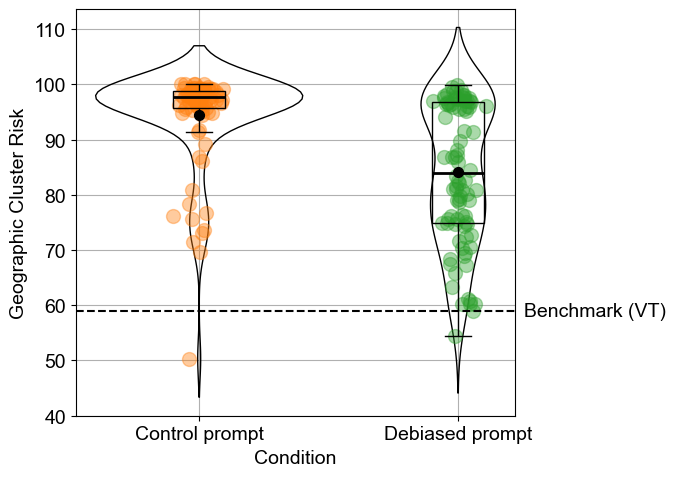

In [17]:
show_benchmark_violinplot(
    geo_us, 
    geo_benchmark_us, 
    'Benchmark (VT)', 
    'weight',
    'Geographic Cluster Risk', #US assets portfolio share [%]
    'cond',
    'study2b_geoRisk'
)

In [18]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'cond', 'risk-taking')

                sum_sq     df         F        PR(>F)
label      7855.367892    5.0  15.14075  2.433172e-12
Residual  18055.037294  174.0       NaN           NaN
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
          group1                     group2           meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)   1.6395 0.9892  -5.9398   9.2189  False
  (Control prompt, averse)  (Control prompt, seeking)  -5.7648 0.2469 -13.3442   1.8145  False
  (Control prompt, averse)  (Debiased prompt, averse)  -6.3513 0.1568 -13.9307    1.228  False
  (Control prompt, averse) (Debiased prompt, neutral)  -17.899    0.0 -25.4784 -10.3196   True
  (Control prompt, averse) (Debiased prompt, seeking) -11.2871 0.0004 -18.8665  -3.7077   True
 (Control prompt, neutral)  (Control prompt, seeking)  -7.4044 0.0597 -14.9838

In [19]:
unused = print_stats(geo_us, 'weight', geo_benchmark_us, 'cond', 'age')

                sum_sq     df        F        PR(>F)
label      5624.810836    5.0  9.64938  3.796367e-08
Residual  20285.594350  174.0      NaN           NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)  -2.1226 0.9735 -10.1565  5.9114  False
 (Control prompt, 15)  (Control prompt, 50)  -2.3438 0.9594 -10.3777  5.6902  False
 (Control prompt, 15) (Debiased prompt, 15)  -8.6667 0.0263 -16.7006 -0.6328   True
 (Control prompt, 15) (Debiased prompt, 30) -14.9148    0.0 -22.9488 -6.8809   True
 (Control prompt, 15) (Debiased prompt, 50)  -12.297 0.0003  -20.331 -4.2631   True
 (Control prompt, 30)  (Control prompt, 50)  -0.2212    1.0  -8.2551  7.8127  False
 (Control prompt, 30) (Debiased prompt, 15)  -6.5441 0.1811 -14.5781  1.4898  False
 

## Sector cluster risk

In [20]:
def prepare_sector_data(df, is_benchmark = False):
    if not is_benchmark:
        df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    df = df[df['sector'] != 'UNKNOWN'] 
    print(df.shape)
    return df

def calculate_concentration(result, group):
    result['weight_squared'] = result['weight'] ** 2
    result_sum = result.groupby(group)['weight'].sum().reset_index()
    result_sum = result_sum['weight'] ** 2
    result_grouped = result.groupby(group)['weight_squared'].sum().reset_index()
    result_grouped['concentration'] = result_grouped['weight_squared'] / result_sum
    return result_grouped

benchmark_filtered = prepare_sector_data(vt_dummy, True)
sec_benchmark = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_benchmark = calculate_concentration(sec_benchmark, group_cols)
sec_benchmark = sec_benchmark.iloc[0]['concentration']

filtered_df = prepare_sector_data(ageRisk_resolved)
sec = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
#sec = prepare_dataframe(sec, 'weight', 'sector', sec['sector'].unique()) #left out as before
sec = calculate_concentration(sec, group_cols)

(9621, 15)
(1666128, 35)


TtestResult(statistic=6.83572324937883, pvalue=1.2544479290707515e-10, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 6.84, p_value: 0.0, df: 178
group: ('Control prompt',) got t: 11.3 p_value: 0.0 dfs: 89 benchmark: 0.15 d: 0.17
group: ('Debiased prompt',) got t: 4.12 p_value: 0.0001 dfs: 89 benchmark: 0.15 d: 0.04
means:
cond
Control prompt     0.32
Debiased prompt    0.20
Name: concentration, dtype: float64
stds:
cond
Control prompt     0.14
Debiased prompt    0.10
Name: concentration, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: concentration, dtype: int64


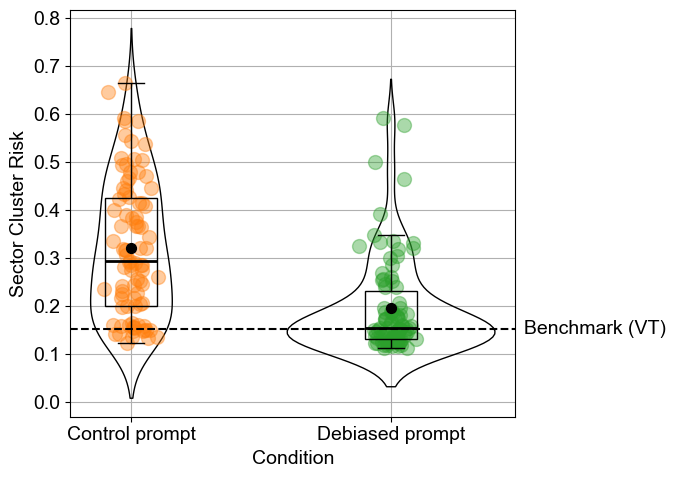

In [21]:
show_benchmark_violinplot(
    sec, 
    sec_benchmark, 
    'Benchmark (VT)', 
    'concentration',
    'Sector Cluster Risk', #Sector Concentration 
    'cond',
    'study2b_sectorRisk'
)

In [22]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'cond', 'risk-taking')

            sum_sq     df          F        PR(>F)
label     1.688217    5.0  35.730752  4.651356e-25
Residual  1.644240  174.0        NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                     group2           meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)   0.1497    0.0  0.0774   0.222   True
  (Control prompt, averse)  (Control prompt, seeking)   0.2239    0.0  0.1516  0.2963   True
  (Control prompt, averse)  (Debiased prompt, averse)  -0.0475 0.4091 -0.1199  0.0248  False
  (Control prompt, averse) (Debiased prompt, neutral)  -0.0186 0.9767 -0.0909  0.0538  False
  (Control prompt, averse) (Debiased prompt, seeking)   0.0675 0.0829 -0.0049  0.1398  False
 (Control prompt, neutral)  (Control prompt, seeking)   0.0742 0.0405  0.0019  0.1466   True
 (Control 

In [23]:
unused = print_stats(sec, 'concentration', sec_benchmark, 'cond', 'age')

            sum_sq     df          F        PR(>F)
label     0.787973    5.0  10.776823  4.851629e-09
Residual  2.544484  174.0        NaN           NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)  -0.0584 0.4232 -0.1484  0.0315  False
 (Control prompt, 15)  (Control prompt, 50)  -0.0542 0.5096 -0.1442  0.0358  False
 (Control prompt, 15) (Debiased prompt, 15)  -0.1367 0.0003 -0.2267 -0.0467   True
 (Control prompt, 15) (Debiased prompt, 30)  -0.1667    0.0 -0.2567 -0.0767   True
 (Control prompt, 15) (Debiased prompt, 50)  -0.1816    0.0 -0.2715 -0.0916   True
 (Control prompt, 30)  (Control prompt, 50)   0.0042    1.0 -0.0858  0.0942  False
 (Control prompt, 30) (Debiased prompt, 15)  -0.0783 0.1279 -0.1682  0.0117  False
 (Control prompt,

## Concentration Map

In [24]:
def prepare_overview_data(df, isBenchmark = False):
    filtered_df = df.copy()
    if not isBenchmark:
        filtered_df = df[df['asset_type'].isin(['ETF', 'EQUITY', 'MUTUALFUND'])]
    filtered_df = filtered_df[filtered_df['country'] != 'UNKNOWN'] 
    filtered_df = filtered_df[filtered_df['sector'] != 'UNKNOWN']
    filtered_df['country'] = filtered_df['country'].apply(lambda x: 'US' if x == 'UNITED STATES' else 'Non-US')
    print(filtered_df.shape)
    return filtered_df

def calc_overview(raw, column, column_label, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    
    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

def show_matched_ttest(raw, column, benchmark):
    for group_name, group_data in raw.groupby(column):
        group_values = group_data['weight']
        benchmark_val = 0
        if len(benchmark[benchmark[column] == group_name]) > 0:
            benchmark_val = benchmark[benchmark[column] == group_name].iloc[0]['weight']
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        print(f'group: {group_name} with mean {round(group_values.mean(),4)} and std {round(group_values.std(),4)} got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 4)}')

filtered_df = prepare_overview_data(ageRisk_resolved)

sec_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
sec_ov = fill_options(filtered_df, sec_ov, 'sector', group_cols)
calc_overview(sec_ov, 'weight','weight','sector')

bench_sec_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='sector').reset_index()
show_matched_ttest(sec_ov, 'sector', bench_sec_ov)

geo_ov = filtered_df.groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
gec_ov = fill_options(filtered_df, geo_ov, 'country', group_cols)
calc_overview(geo_ov, 'weight','weight','country')

bench_geo_ov = prepare_overview_data(vt_dummy, True).groupby(group_cols).apply(calculate_weight, elem='country').reset_index()
show_matched_ttest(geo_ov, 'country', bench_geo_ov)


(1644086, 35)
             sum_sq      df           F  PR(>F)
label     16.335420    13.0  182.069596     0.0
Residual  17.295399  2506.0         NaN     NaN
                                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                                     
                  group1                                     group2                   meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------
           Academic & Educational Services                            Basic Materials   0.0148 0.9191 -0.0146  0.0442  False
           Academic & Educational Services                     Communication Services   0.0183 0.7051 -0.0111  0.0477  False
           Academic & Educational Services                          Consumer Cyclical   0.1963    0.0  0.1669  0.2257   True
           Academic & Educational Services                     Consumer Non-Cyclicals   0.04

In [25]:
def show_condition_matched_ttest(raw, column, cond_col):
    conds = raw[cond_col].unique()
    cond_1, cond_2 = conds[:2]
    elems = raw[column].unique()
    for elem in elems:
        data_1 = raw[(raw[cond_col] == cond_1) & (raw[column] == elem)]['weight']
        data_2 = raw[(raw[cond_col] == cond_2) & (raw[column] == elem)]['weight']
        t_stat, p_value = stats.ttest_ind(data_1, data_2)
        print(f'for {elem}: t={round(t_stat,2)}, p-value={round(p_value, 4)}, dif={round(data_2.mean() - data_1.mean(), 2)}')

show_condition_matched_ttest(sec_ov, 'sector', 'cond')

for Technology: t=3.6, p-value=0.0004, dif=-0.08
for Consumer Cyclical: t=3.29, p-value=0.0012, dif=-0.09
for Consumer Non-Cyclicals: t=-0.72, p-value=0.4703, dif=0.01
for Healthcare: t=-0.3, p-value=0.7624, dif=0.0
for Financials: t=-5.32, p-value=0.0, dif=0.03
for Energy: t=-3.85, p-value=0.0002, dif=0.01
for Basic Materials: t=-8.16, p-value=0.0, dif=0.01
for Utilities: t=-1.51, p-value=0.1335, dif=0.01
for Industrials: t=-8.19, p-value=0.0, dif=0.02
for Real Estate: t=-4.28, p-value=0.0, dif=0.05
for Academic & Educational Services: t=-6.72, p-value=0.0, dif=0.0
for Government Activity: t=-3.02, p-value=0.0029, dif=0.04
for Institutions, Associations & Organizations: t=-3.1, p-value=0.0022, dif=0.0
for Communication Services: t=0.94, p-value=0.3478, dif=-0.01


(9485, 15)


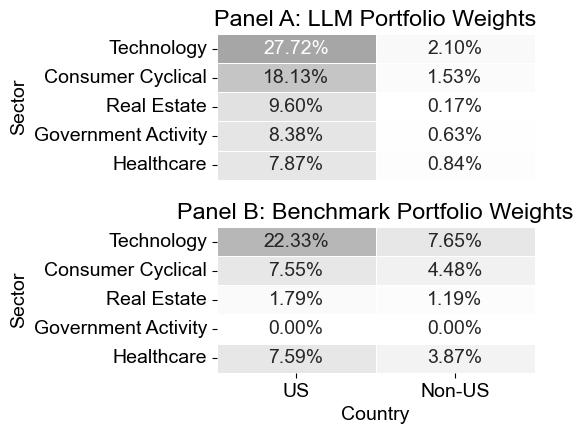

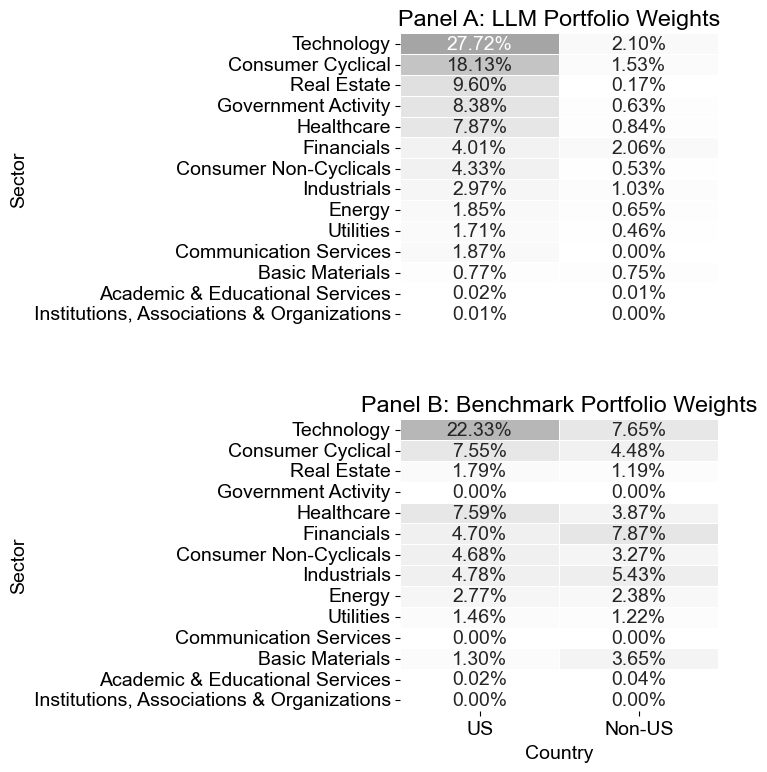

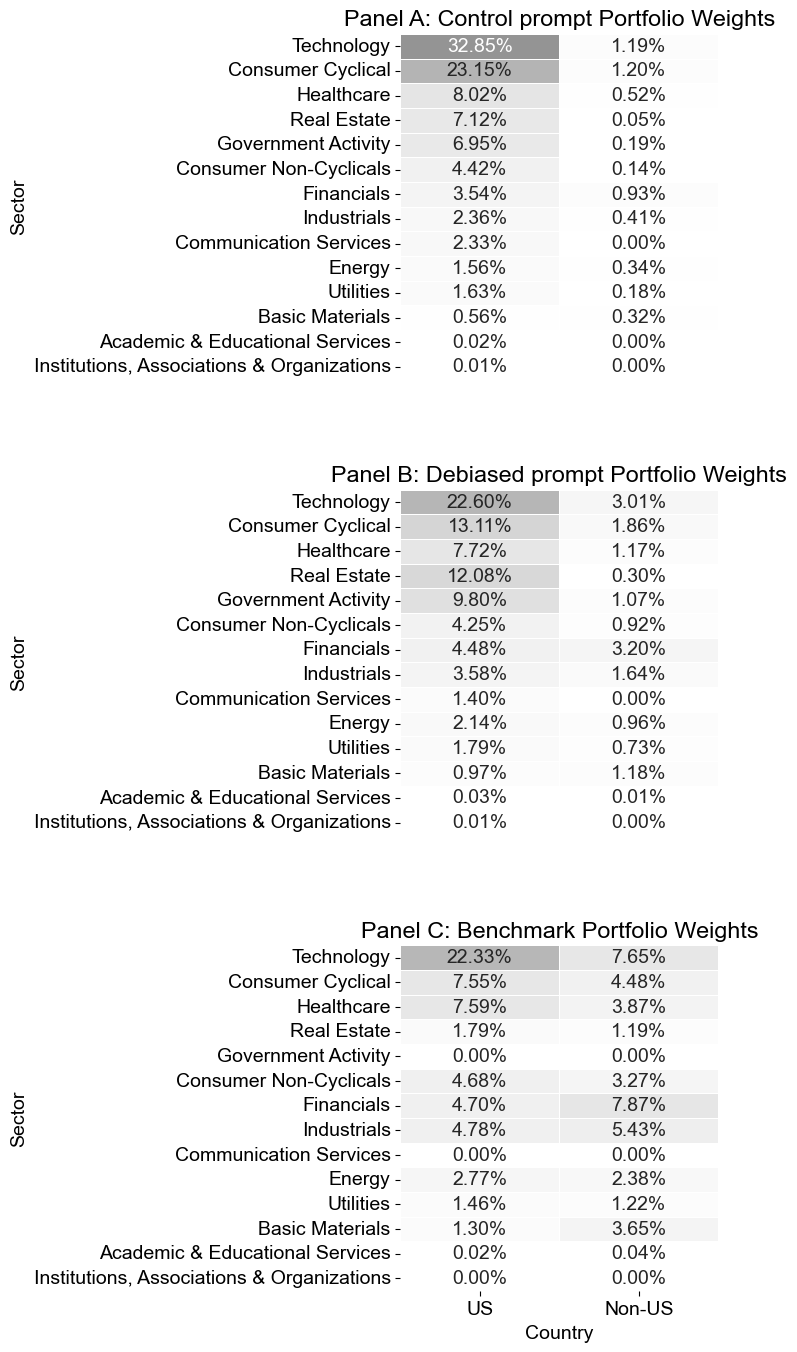

In [26]:
def fill_concentration(filtered_df, res, group_cols):
    sectors = filtered_df['sector'].unique()
    countries = filtered_df['country'].unique()
    group_cols_df = filtered_df[group_cols].drop_duplicates()
    all_combinations = pd.DataFrame(
        [row + [sector, country] for row in group_cols_df.values.tolist() for sector, country in itertools.product(sectors, countries)], 
        columns=group_cols+['sector', 'country'])

    merged_df = pd.merge(all_combinations, res, on=group_cols+['sector', 'country'], how='left')
    merged_df.fillna(0, inplace=True)
    return merged_df

def custom_heatmap(data, color_map="gray_r", annot=True, fmt=".2%", ax=None, max_color=None, **kwargs):
    sns.heatmap(data, cmap=color_map, annot=annot, fmt=fmt, linewidths=.5, cbar=False, ax=ax, vmax=max_color, **kwargs)

import numpy as np

def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).nlargest(5).index
    else:
        row_order = first_facet_pivot.sum(axis=1).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='sector', columns='country', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(index=row_order, fill_value=0)
        facet_pivot = facet_pivot.reindex(columns=facet_pivot.columns[::-1], fill_value=0)  # Reverse column order
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)        
        ax.set_yticks(np.arange(len(facet_pivot.index)) + 0.5)
        ax.set_yticklabels(facet_pivot.index, va='center')  # Set y-tick labels
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    g.set_axis_labels("Country", "Sector")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined = pd.concat([concentration_overview, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined, 'study2b_overview_concentration_map', True, 4, 4)
show_faceted_heatmap(combined, 'study2b_concentration_map', False, 4, 8)

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study2b_concentration_map_details', False, 4, 14)

(9485, 15)


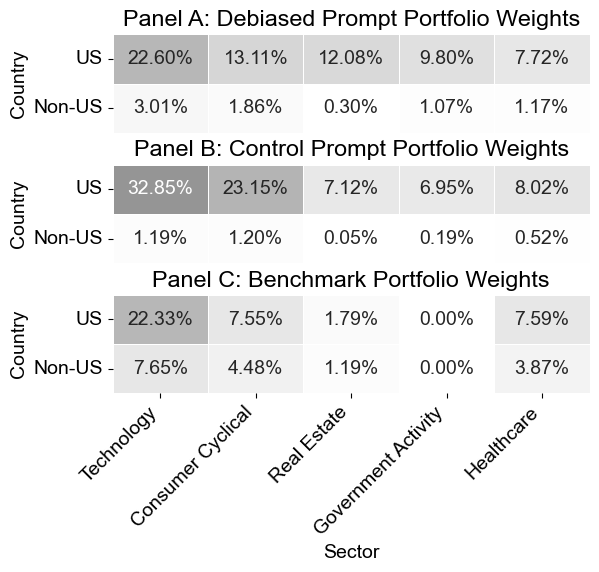

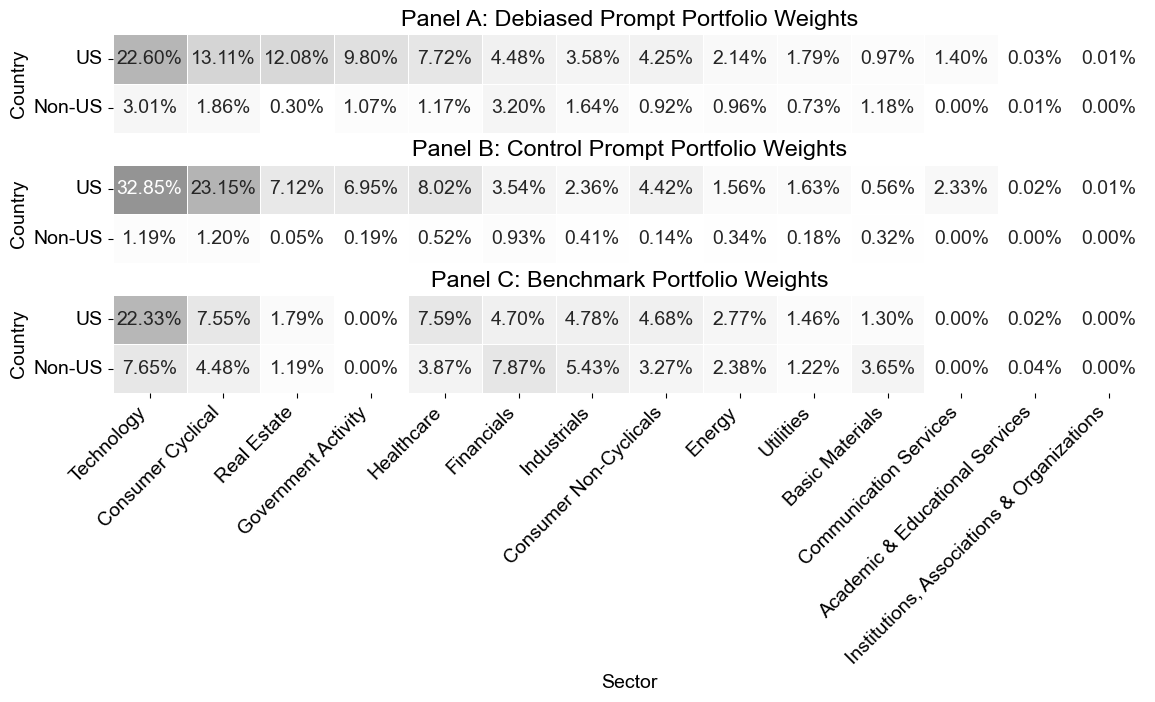

In [27]:
def show_faceted_heatmap(combined_df, filename, show_top, width, height):
    all_sectors = combined_df['sector'].unique()
    combined_df = combined_df.sort_values(by='type', ascending=False)
    replacements = {'Control prompt': 'Control Prompt', 'Debiased prompt': 'Debiased Prompt'}
    combined_df['type'] = combined_df['type'].replace(replacements)

    g = sns.FacetGrid(combined_df, col="type", col_wrap=1, height=3, aspect=1.5, sharey=True)
    g.fig.set_size_inches(width, height)
    
    first_facet_data = combined_df[combined_df['type'] == combined_df['type'].unique()[0]]
    first_facet_pivot = first_facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
    max_color_value = combined_df['weight'].max()

    if show_top:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).nlargest(5).index
    else:
        column_order = first_facet_pivot.sum(axis=0).sort_values(ascending=False).index

    for i, (ax, facet_name) in enumerate(zip(g.axes, combined_df['type'].unique())):
        ax.set_title(f'Panel {string.ascii_uppercase[i]}: {facet_name} Portfolio Weights')        
        facet_data = combined_df[combined_df['type'] == facet_name]
        facet_pivot = facet_data.pivot_table(index='country', columns='sector', values='weight', fill_value=0)
        facet_pivot = facet_pivot.sort_index(ascending=False)
        facet_pivot = facet_pivot.reindex(columns=column_order, fill_value=0)
        custom_heatmap(facet_pivot, ax=ax, max_color=max_color_value)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
        if i == len(combined_df['type'].unique()) - 1:
            if ax.get_xticklabels():
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)

    g.set_axis_labels("Sector", "Country")
    plt.savefig(f'./figures/{filename}.png', bbox_inches='tight')

benchmark_filtered = prepare_overview_data(vt_dummy, True)
benchmark_concentration = benchmark_filtered.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
benchmark_concentration = fill_concentration(benchmark_filtered, benchmark_concentration, group_cols)
benchmark_concentration['type'] = 'Benchmark'

concentration = filtered_df.groupby(group_cols).apply(calculate_weight, elem=['sector', 'country']).reset_index()
concentration = fill_concentration(filtered_df, concentration, group_cols)
concentration_overview = concentration.copy()
concentration_overview['type'] = 'LLM'
concentration_details = concentration.copy()
concentration_details['type'] = concentration_details['cond'] 

combined_details = pd.concat([concentration_details, benchmark_concentration], ignore_index=True)

show_faceted_heatmap(combined_details, 'study2b_overview_concentration_map_horizontal', True, 6, 4)
show_faceted_heatmap(combined_details, 'study2b_details_concentration_map_horizontal', False, 13, 4)

## Active investment allocation risk

In [28]:
ter_data_study1 = pd.read_csv('../study1/etf_holdings/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study1 = ter_data_study1.iloc[1:].reset_index()
ter_data_study1.columns = ['fund', 'fund_type', 'ter', 'management_approach']
ter_data_study1 = ter_data_study1[~ter_data_study1['management_approach'].isna()]
ter_data_study2b = pd.read_csv('./data/refinitiv/funds_ter_refinitiv.csv', index_col=0)
ter_data_study2b = ter_data_study2b.iloc[1:].reset_index()
ter_data_study2b.columns = ['fund', 'fund_type', 'ter', 'management_approach']

ter_data = pd.concat([ter_data_study1, ter_data_study2b], ignore_index=True)
ter_data['fund'] = ter_data['fund'].str.split('.').str[0]
condition = ter_data['ter'].str.startswith('Unable to')
ter_data.loc[condition & ~ter_data['ter'].isna(), 'ter'] = np.nan

In [29]:
def set_management_approach(row):
    if row['asset_type'] in ['EQUITY', 
                               'CRYPTOCURRENCY', 
                               'BOND', 
                               'MONEYMARKET', 
                               'SEEDINVEST', 
                               'REALESTATE', 
                               'ROBO', 
                               'VENTURECAPITAL',
                               'PRIVATEEQUITY']:
        return 'Active'
    else:
        ticker = row['ticker_symbol']
        if ticker in ter_data['fund'].unique():
            approach = ter_data[ter_data['fund'] == ticker].iloc[0]['management_approach']
            return approach
        else:
            return 'UNKNOWN'

def calculate_approach_weight(group):
    summed = group.groupby('management_approach')['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['management_weight'] = summed['amount_to_invest'] / total_amount
    return summed

def get_management_data(df, groups):
    df = df[df['management_approach'] != 'UNKNOWN']
    management_data = df.groupby(groups).apply(calculate_approach_weight).reset_index()
    return management_data      

investment_ageRisk = ageRisk[~ageRisk['asset_type'].isin(['SAVING', 'DEPOSIT', 'IRA', 'ANNUITY'])]
investment_ageRisk = investment_ageRisk.copy()
investment_ageRisk['management_approach'] = investment_ageRisk.apply(set_management_approach, axis=1)
management_data = get_management_data(investment_ageRisk, group_cols)
management_data = prepare_dataframe(management_data, 'management_weight', 'management_approach', ['Active', 'Passive'])
management_data = management_data[management_data['management_approach'] == 'Active']
management_data['management_weight'] = management_data['management_weight'] *100

TtestResult(statistic=7.392692911898354, pvalue=5.415356908592153e-12, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 7.39, p_value: 0.0, df: 178
group: ('Control prompt',) got t: 17.64 p_value: 0.0 dfs: 89 benchmark: 0 d: 58.12
group: ('Debiased prompt',) got t: 8.41 p_value: 0.0 dfs: 89 benchmark: 0 d: 25.19
means:
cond
Control prompt     58.12
Debiased prompt    25.19
Name: management_weight, dtype: float64
stds:
cond
Control prompt     31.25
Debiased prompt    28.43
Name: management_weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: management_weight, dtype: int64


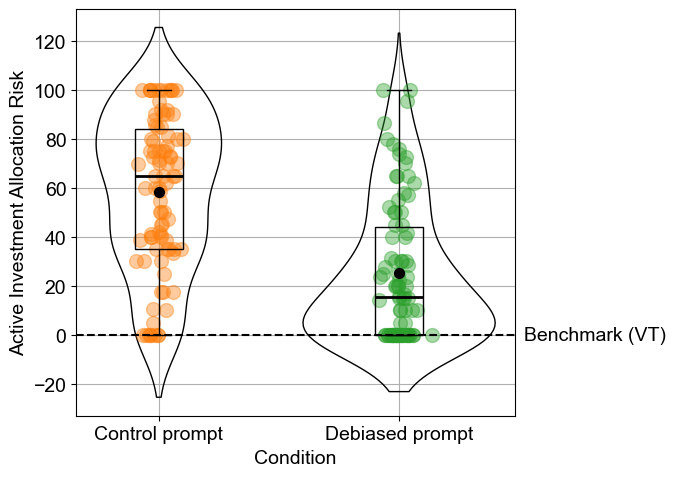

In [30]:
show_benchmark_violinplot(
    management_data, 
    0, 
    'Benchmark (VT)', 
    'management_weight',
    'Active Investment Allocation Risk', #Active management portfolio weight [%]
    'cond',
    'study2b_activeRisk'
)

In [31]:
unused = print_stats(management_data, 'management_weight', 0, 'cond', 'risk-taking')

                 sum_sq     df          F        PR(>F)
label     122475.681253    5.0  50.046084  6.061824e-32
Residual   85164.579125  174.0        NaN           NaN
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
          group1                     group2           meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)  38.2543    0.0   21.793  54.7156   True
  (Control prompt, averse)  (Control prompt, seeking)  56.8984    0.0  40.4371  73.3597   True
  (Control prompt, averse)  (Debiased prompt, averse) -13.2509 0.1918 -29.7122   3.2105  False
  (Control prompt, averse) (Debiased prompt, neutral) -11.8589 0.3047 -28.3202   4.6024  False
  (Control prompt, averse) (Debiased prompt, seeking)  21.4936 0.0031   5.0323  37.9549   True
 (Control prompt, neutral)  (Control prompt, seeking)  18.6441 0.0164   

In [32]:
unused = print_stats(management_data, 'management_weight', 0, 'cond', 'age')

                 sum_sq     df          F        PR(>F)
label      54072.526201    5.0  12.253381  3.477499e-10
Residual  153567.734177  174.0        NaN           NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)  -7.3262 0.9312 -29.4309  14.7785  False
 (Control prompt, 15)  (Control prompt, 50) -13.4893 0.4953  -35.594   8.6154  False
 (Control prompt, 15) (Debiased prompt, 15) -32.4504 0.0005 -54.5551 -10.3457   True
 (Control prompt, 15) (Debiased prompt, 30) -44.7802    0.0  -66.885 -22.6755   True
 (Control prompt, 15) (Debiased prompt, 50) -42.3537    0.0 -64.4584  -20.249   True
 (Control prompt, 30)  (Control prompt, 50)  -6.1631 0.9666 -28.2678  15.9416  False
 (Control prompt, 30) (Debiased prompt, 15) -25.1242 0.0158 -47.228

## Total Expense Risk

In [33]:
fund_identifiers = ter_data['fund'].unique()
def assign_ter(row):
    ticker = row['ticker_symbol']
    if ticker in fund_identifiers:
        return ter_data[ter_data['fund'] == ticker].iloc[0]['ter']
    else: 
        return np.nan

def calculate_fund_weight(group, elem):
    summed = group.groupby(elem)['amount_to_invest'].sum().reset_index()
    total_amount = summed['amount_to_invest'].sum()
    summed['weight'] = summed['amount_to_invest'] / total_amount
    return summed

ter_benchmark = float(ter_data[ter_data['fund'] == 'VT'].iloc[0]['ter'])
ter_benchmark = ter_benchmark

filtered_df = ageRisk[ageRisk['asset_type'].isin(['ETF', 'MUTUALFUND'])]
ter_df = filtered_df.copy()
ter_df = ter_df.groupby(group_cols).apply(calculate_fund_weight, elem='ticker_symbol').reset_index()
ter_df['ter'] = ter_df.apply(assign_ter, axis=1)
ter_df['ter'] = ter_df['ter'].astype(float)
ter_df['ter_weight'] = ter_df['ter'] * ter_df['weight']
grouped_ter = ter_df.groupby(group_cols)['ter_weight'].sum().reset_index()

TtestResult(statistic=2.425493815930062, pvalue=0.016321502281615472, df=172.0)
group1: Control prompt and group2: Debiased prompt got t: 2.43, p_value: 0.0163, df: 172
group: ('Control prompt',) got t: 5.74 p_value: 0.0 dfs: 83 benchmark: 0.07 d: 0.13
group: ('Debiased prompt',) got t: 4.52 p_value: 0.0 dfs: 89 benchmark: 0.07 d: 0.07
means:
cond
Control prompt     0.20
Debiased prompt    0.14
Name: ter_weight, dtype: float64
stds:
cond
Control prompt     0.21
Debiased prompt    0.14
Name: ter_weight, dtype: float64
cond
Control prompt     84
Debiased prompt    90
Name: ter_weight, dtype: int64


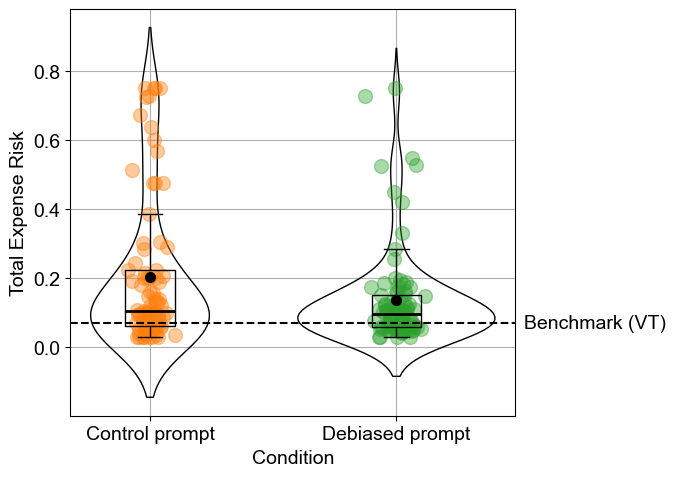

In [34]:
show_benchmark_violinplot(
    grouped_ter, 
    ter_benchmark, 
    'Benchmark (VT)', 
    'ter_weight',
    'Total Expense Risk', #TER % 
    'cond',
    'study2b_terRisk'
)

In [35]:
# Control for different N (portfolios being excluded due to no investment in ETFs or mutual funds
ter_control = grouped_ter[grouped_ter['cond'] == 'Control prompt']['ter_weight']
ter_debiased = grouped_ter[grouped_ter['cond'] == 'Debiased prompt']['ter_weight']

stat, p = stats.mannwhitneyu(ter_control, ter_debiased)
print(f'control-debiased: {stat}, {p}')

# Perform one-sample Wilcoxon signed-rank test
stat_bench, p_bench = stats.wilcoxon(ter_control - ter_benchmark)
print(f'control-benchmark: {stat_bench}, {p_bench}')

stat_debiased_bench, p_debiased_bench = stats.wilcoxon(ter_debiased - ter_benchmark)
print(f'debiased-benchmark: {stat_debiased_bench}, {p_debiased_bench}')

# Perform Chi-Square test
count_control = [90-ter_control.size, ter_control.size]
count_debiased = [90-ter_debiased.size, ter_debiased.size]

chi2_stat, p_chi, df_chi, expected = stats.chi2_contingency([count_control, count_debiased])
print(f'chi-square: {chi2_stat}, {p_chi}, df:{df_chi}')

control-debiased: 4280.0, 0.1324639101958332
control-benchmark: 601.0, 1.285682893820706e-07
debiased-benchmark: 856.5, 1.6489952202084282e-06
chi-square: 4.310344827586207, 0.03788128231538694, df:1


In [36]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'cond', 'risk-taking')

            sum_sq     df         F        PR(>F)
label     2.563917    5.0  27.66982  2.226368e-20
Residual  3.113414  168.0       NaN           NaN
                    Multiple Comparison of Means - Tukey HSD, FWER=0.05                     
          group1                     group2           meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)   0.0586 0.5743 -0.0445  0.1617  False
  (Control prompt, averse)  (Control prompt, seeking)   0.3502    0.0   0.245  0.4554   True
  (Control prompt, averse)  (Debiased prompt, averse)   0.0021    1.0 -0.0992  0.1034  False
  (Control prompt, averse) (Debiased prompt, neutral)   0.0211 0.9909 -0.0802  0.1224  False
  (Control prompt, averse) (Debiased prompt, seeking)   0.1634 0.0001   0.062  0.2647   True
 (Control prompt, neutral)  (Control prompt, seeking)   0.2916    0.0  0.1847  0.3985   True
 (Control pro

In [37]:
unused = print_stats(grouped_ter, 'ter_weight', ter_benchmark, 'cond', 'age')

            sum_sq     df         F    PR(>F)
label     0.243567    5.0  1.506112  0.190445
Residual  5.433764  168.0       NaN       NaN
               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)   0.0218 0.9976 -0.1168 0.1604  False
 (Control prompt, 15)  (Control prompt, 50)  -0.0274 0.9929 -0.1659 0.1112  False
 (Control prompt, 15) (Debiased prompt, 15)  -0.0456 0.9283 -0.1818 0.0906  False
 (Control prompt, 15) (Debiased prompt, 30)  -0.0795  0.546 -0.2157 0.0568  False
 (Control prompt, 15) (Debiased prompt, 50)  -0.0777 0.5704  -0.214 0.0585  False
 (Control prompt, 30)  (Control prompt, 50)  -0.0492 0.9096 -0.1877 0.0894  False
 (Control prompt, 30) (Debiased prompt, 15)  -0.0674 0.7109 -0.2036 0.0688  False
 (Control prompt, 30) (Debiased prompt, 30

## Trend chasing risk

In [38]:
vt_prepared = benchmark_vt
vt_prepared['symbol'] = vt_prepared['symbol'].str.split('.').str[0]
vt_prepared = vt_prepared['symbol'].unique()

volume_dict = {}
start_date = "2023-04-01"
end_date = "2023-06-30"

In [39]:
json_file_path = '../study1/benchmark/vt_benchmark_holdings_volume_202304_3m.json'

# Open and read the JSON file
with open(json_file_path, 'r') as json_file:
    # Load the JSON data into a dictionary
    volume_dict = json.load(json_file)
    
most_active_stocks = sorted(volume_dict.items(), key=lambda x: x[1], reverse=True)

# Most traded in the last 3 months by volume
most_traded = []
for i, (symbol, volume) in enumerate(most_active_stocks[:20], 1):
    most_traded.append(symbol)
    print(f"{i}. Symbol: {symbol}, Total Volume: {volume}")

1. Symbol: TSLA, Total Volume: 8627649000
2. Symbol: PLTR, Total Volume: 4490639300
3. Symbol: AMD, Total Volume: 4201460900
4. Symbol: AMZN, Total Volume: 3899624000
5. Symbol: F, Total Volume: 3708650700
6. Symbol: AAPL, Total Volume: 3541966300
7. Symbol: NIO, Total Volume: 3235177200
8. Symbol: SOFI, Total Volume: 3204363300
9. Symbol: BAC, Total Volume: 3044131000
10. Symbol: NKLA, Total Volume: 3010655200
11. Symbol: NVDA, Total Volume: 2965437300
12. Symbol: INTC, Total Volume: 2762170900
13. Symbol: CCL, Total Volume: 2498772900
14. Symbol: T, Total Volume: 2442695800
15. Symbol: GOOGL, Total Volume: 2081408400
16. Symbol: LCID, Total Volume: 1905241200
17. Symbol: AI, Total Volume: 1890107300
18. Symbol: NU, Total Volume: 1711794600
19. Symbol: MSFT, Total Volume: 1699893000
20. Symbol: PACW, Total Volume: 1662858500


In [40]:
def getTop(conds, cond, equities_cond, equities_grouped):
    top_data = {}
    
    for co in conds:
        top_equities_total = equities_cond[equities_cond['cond'] == co]['amount_to_invest']
        top_total = cond[cond['cond'] == co]['amount_to_invest']
        top_cond = equities_grouped[equities_grouped['cond'] == co]
        top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
        top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
        top_cond = top_cond.sort_values(by='amount_to_invest', ascending=False)
        top_data[co] = top_cond
        
    return top_data

def showTop(conds, top_data):
    top_dict = {}
    for co in conds:
        top = top_data[co]
        top_equities_sum = top['pct_of_equities'].sum()
        top_total_sum = top['pct_of_total'].sum()
        print(f'{co} top: % of equities: {top_equities_sum} and % of total {top_total_sum}')

        top3 = top.head(3)
        top3 = top3[top3['ticker_symbol'].isin(most_traded)]
        top3_equities_sum = top3['pct_of_equities'].sum()
        top3_total_sum = top3['pct_of_total'].sum()
        print(f'{co} top 3: % of equities: {top3_equities_sum} and % of total {top3_total_sum}')
        print(f'{top3}\n')
        top_dict[co] = top3['ticker_symbol'].tolist()
    return top_dict

conds = ageRisk['cond'].unique()
ageRisk_cond = ageRisk.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities = ageRisk[ageRisk['asset_type'] == 'EQUITY']
ageRisk_equities_cond = ageRisk_equities.groupby(['cond'])['amount_to_invest'].sum().reset_index()
ageRisk_equities_grouped = ageRisk_equities.groupby(['cond','ticker_symbol'])['amount_to_invest'].sum().reset_index()

top_data = getTop(conds, ageRisk_cond, ageRisk_equities_cond, ageRisk_equities_grouped)
top_dict = showTop(conds, top_data)

Control prompt top: % of equities: 1.0 and % of total 0.42105263157894735
Control prompt top 3: % of equities: 0.6237373737373737 and % of total 0.2626262626262626
              cond ticker_symbol  amount_to_invest  pct_of_equities  \
0   Control prompt          AAPL          104500.0         0.263889   
25  Control prompt          TSLA           82500.0         0.208333   
2   Control prompt          AMZN           60000.0         0.151515   

    pct_of_total  
0       0.111111  
25      0.087719  
2       0.063796  

Debiased prompt top: % of equities: 1.0 and % of total 0.15766503000545554
Debiased prompt top 3: % of equities: 0.5743944636678201 and % of total 0.09056192034915439
               cond ticker_symbol  amount_to_invest  pct_of_equities  \
45  Debiased prompt          TSLA           34500.0         0.238754   
28  Debiased prompt          AAPL           25500.0         0.176471   
29  Debiased prompt          AMZN           23000.0         0.159170   

    pct_of_total  

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_16897/3554050832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_equities'] = top_cond['amount_to_invest'].apply(lambda x: x / top_equities_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_16897/3554050832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_cond['pct_of_total'] = top_cond['amount_to_invest'].apply(lambda x : x / top_total)
/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_16897/3554

In [41]:
top3_benchmark = vt_dummy.sort_values(by='weight', ascending=False).head(3) 
top3_benchmark #all included in top 20 most traded

,fund,code,equity,symbol,#shares,weight,country,type,sector,amount,cond,ai,age,risk-taking,iteration
93854,VT,LP40120747,APPLE INC ORD,AAPL,8132495.0,0.038911,UNITED STATES,Ordinary Shares,Technology,389.11,VT,VT,1,low,0
93855,VT,NaN,MICROSOFT CORP ORD,MSFT,4055679.0,0.033854,UNITED STATES,Ordinary Shares,Technology,338.54,VT,VT,1,low,0
93856,VT,NaN,AMAZON.COM INC ORD,AMZN,4909845.0,0.017257,UNITED STATES,Ordinary Shares,Consumer Cyclical,172.57,VT,VT,1,low,0


In [42]:
def calcTopMeans(df, top_dict):
    top_df = None

    for cond, top_assets in top_dict.items():
        filtered_df = df[(df['cond'] == cond) & (df['ticker_symbol'].isin(top_assets))]
        top_df = pd.concat([top_df, filtered_df])
    
    top_df = prepare_dataframe(top_df, 'weight')    
    result = top_df.groupby(['cond', 'age', 'risk-taking', 'iteration'])['weight'].sum().reset_index()
    return result
 
benchmark_trends = top3_benchmark.groupby('cond')['weight'].sum().reset_index().iloc[0]['weight']
trends_data = calcTopMeans(ageRisk_resolved, top_dict)

trends_data['weight'] = trends_data['weight'] *100
benchmark_trends = benchmark_trends * 100

TtestResult(statistic=6.351962595273915, pvalue=1.7215558846627165e-09, df=178.0)
group1: Control prompt and group2: Debiased prompt got t: 6.35, p_value: 0.0, df: 178
group: ('Control prompt',) got t: 7.66 p_value: 0.0 dfs: 89 benchmark: 9.0 d: 16.86
group: ('Debiased prompt',) got t: -0.11 p_value: 0.9148 dfs: 89 benchmark: 9.0 d: -0.16
means:
cond
Control prompt     25.87
Debiased prompt     8.84
Name: weight, dtype: float64
stds:
cond
Control prompt     20.89
Debiased prompt    14.51
Name: weight, dtype: float64
cond
Control prompt     90
Debiased prompt    90
Name: weight, dtype: int64


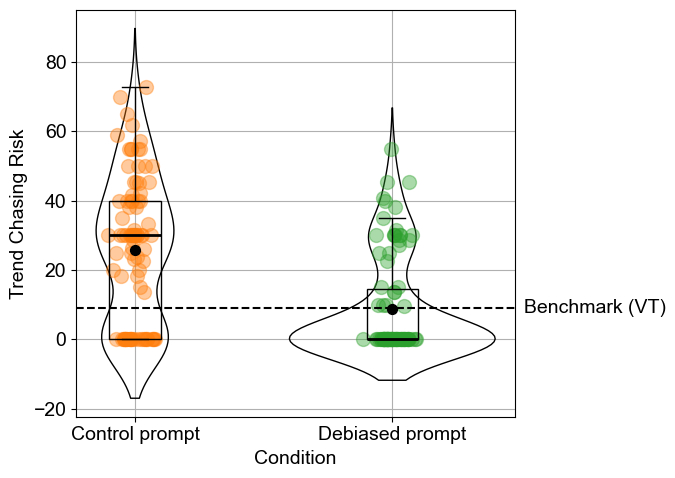

In [43]:
show_benchmark_violinplot(
    trends_data, 
    benchmark_trends, 
    'Benchmark (VT)', 
    'weight',
    'Trend Chasing Risk', #Top 3 trending equities portfolio share [%]
    'cond',
    'study2b_trendRisk'
)

In [44]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'cond', 'risk-taking')

                sum_sq     df          F        PR(>F)
label     41282.522509    5.0  48.993109  1.773538e-31
Residual  29323.139669  174.0        NaN           NaN
                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
          group1                     group2           meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------------------
  (Control prompt, averse)  (Control prompt, neutral)  33.8562    0.0   24.197  43.5154   True
  (Control prompt, averse)  (Control prompt, seeking)   33.946    0.0  24.2869  43.6052   True
  (Control prompt, averse)  (Debiased prompt, averse)  -3.2648 0.9256 -12.9239   6.3944  False
  (Control prompt, averse) (Debiased prompt, neutral)   4.6154 0.7408  -5.0437  14.2746  False
  (Control prompt, averse) (Debiased prompt, seeking)  15.3694 0.0001   5.7103  25.0286   True
 (Control prompt, neutral)  (Control prompt, seeking)   0.0899    1.0  -9.5

In [45]:
unused = print_stats(trends_data, 'weight', benchmark_trends, 'cond', 'age')

                sum_sq     df         F        PR(>F)
label     14287.337029    5.0  8.828376  1.739487e-07
Residual  56318.325149  174.0       NaN           NaN
                Multiple Comparison of Means - Tukey HSD, FWER=0.05                 
        group1                group2        meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------
 (Control prompt, 15)  (Control prompt, 30)   -4.683 0.9147 -18.0693   8.7033  False
 (Control prompt, 15)  (Control prompt, 50)  -5.1235 0.8796 -18.5098   8.2628  False
 (Control prompt, 15) (Debiased prompt, 15) -16.6473 0.0058 -30.0336  -3.2611   True
 (Control prompt, 15) (Debiased prompt, 30) -20.5001 0.0003 -33.8864  -7.1138   True
 (Control prompt, 15) (Debiased prompt, 50) -23.7411    0.0 -37.1274 -10.3548   True
 (Control prompt, 30)  (Control prompt, 50)  -0.4405    1.0 -13.8268  12.9458  False
 (Control prompt, 30) (Debiased prompt, 15) -11.9644 0.1089 -25.3506   1.

## MANOVA

In [46]:
geo_us.rename(columns={'weight': 'us_weight'}, inplace=True)
trends_data.rename(columns={'weight': 'trends_weight'}, inplace=True)
print(geo_us.shape)
print(sec.shape)
print(management_data.shape)
print(grouped_ter.shape)
print(trends_data.shape)

(180, 9)
(180, 7)
(180, 10)
(174, 6)
(180, 6)


In [47]:
df_metrics = geo_us.merge(
    sec[['cond', 'age', 'risk-taking', 'iteration', 'concentration']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    management_data[['cond', 'age', 'risk-taking', 'iteration', 'management_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    grouped_ter[['cond', 'age', 'risk-taking', 'iteration', 'ter_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.merge(
    trends_data[['cond', 'age', 'risk-taking', 'iteration', 'trends_weight']], 
    on=['cond', 'age', 'risk-taking', 'iteration'], 
    how='outer'
)

df_metrics = df_metrics.dropna()
print(df_metrics.shape)

(174, 13)


In [48]:
df_metrics.rename(columns={'risk-taking': 'risk_taking'}, inplace=True)

In [49]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ cond', data = df_metrics)
print(manova.mv_test())

manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ cond + risk_taking + age', data = df_metrics)
print(manova.mv_test())

                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0209 5.0000 168.0000 1572.8784 0.0000
         Pillai's trace  0.9791 5.0000 168.0000 1572.8784 0.0000
 Hotelling-Lawley trace 46.8119 5.0000 168.0000 1572.8784 0.0000
    Roy's greatest root 46.8119 5.0000 168.0000 1572.8784 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
             cond          Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.6967 5.0000 168.0000 14.6273 0.0000
            Pillai's trace 0.3033 5.0000 168.

In [50]:
group_levels = df_metrics['cond'].unique()

# Run MANOVA separately for each level of "cond"
for level in group_levels:
    subset = df_metrics[df_metrics['cond'] == level]  # Subset data for a specific group level
    
    print(f"\nMANOVA for cond: {level}")
    manova = MANOVA.from_formula('us_weight + concentration + management_weight + ter_weight + trends_weight ~ risk_taking + age', data=subset)
    print(manova.mv_test())
    


MANOVA for cond: Control prompt
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0366 5.0000 76.0000 399.6975 0.0000
         Pillai's trace  0.9634 5.0000 76.0000 399.6975 0.0000
 Hotelling-Lawley trace 26.2959 5.0000 76.0000 399.6975 0.0000
    Roy's greatest root 26.2959 5.0000 76.0000 399.6975 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
      risk_taking       Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.1659 10.0000 152.0000 22.1175 0.0000
         Pillai's trace 1.0533 10.0000 15